In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import workCon
import os
from eval import get_model_from_run
from tqdm import tqdm
import ipdb
import traceback
import random
import math
import generate_dataset
from scipy.integrate import solve_ivp
import pickle
import plotly.graph_objects as go

/home/esmith/.conda/envs/icl_ebonye_pendulum/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)

    
    # move the data to specified device
    # data_on_device = tuple(
    #     item.to("cuda:0") if isinstance(item, torch.Tensor) else item for item in data
    # )
    # return data_on_device

    for i, item in enumerate(data):
        if isinstance(item, torch.Tensor):
            print(f"Tensor {i}: shape={item.shape}, dtype={item.dtype}, min={item.min()}, max={item.max()}, device={item.device}")
            if torch.isnan(item).any():
                print(f" - Contains NaNs")
    return data

In [3]:
# # data_path = "/home/esmith/incontextlearning/transformer_control/dataset_pendulum/picklefolder"
# data_path = "/data/esmith/dataset_pendulum/picklefolder"
# cartpoles = np.random.randint(0, 50000, 10)
# data = []
# for i in tqdm(cartpoles):
#     try:
#         data.append(load_data(os.path.join(data_path, f"multipendulum_{i}.pkl")))
#     except Exception as e:
#         print(f"Error loading {i}: {e}")
#         continue

# print(len(data))

In [4]:
# print(f"Len of data[0]: {len(data[0])}")
# print(f"Shape of data[0][0]: {data[0][0].shape}")

In [5]:
# ## visualize theta and theta_dot phase plot

# def plot_theta_and_theta_dot(data):
#     fig = go.Figure()
#     for i in range(len(data)):
#         theta = torch.squeeze(data[i][0])[:, 1].cpu().numpy()
#         theta_dot = torch.squeeze(data[i][0])[:, 3].cpu().numpy()
#         fig.add_trace(go.Scatter(x=theta, y=theta_dot, mode='lines', name=f'Cartpole {i}'))
#     fig.update_layout(title='Theta vs Theta Dot Phase Plot',
#                       xaxis_title='Theta',
#                       yaxis_title='Theta Dot')
#     fig.show()
# plot_theta_and_theta_dot(data)

In [6]:
# ## visualize control inputs
# def plot_control_inputs(data):
#     fig = go.Figure()
#     for i in range(len(data)):
#         control_input = torch.squeeze(data[i][1]).cpu().numpy()
#         fig.add_trace(go.Scatter(x=np.arange(len(control_input)), y=np.abs(control_input), mode='lines', name=f'Cartpole {i}'))
#     fig.update_layout(title='Control Inputs',
#                       xaxis_title='Time Step',
#                       yaxis_title='Control Input',
#                       yaxis_type='log')
#     fig.show()

# def plot_control_inputs_scaled(data):
#     fig = go.Figure()
#     fig2 = go.Figure()
#     for i in range(len(data)):
#         control_input = torch.squeeze(data[i][1]).cpu().numpy()
#         scaled_control_input = (control_input )/ (300) ### approximate min-max scaling
#         scaled_control_input2 = [control_input[i]/(1*0.95**i) for i in range(len(control_input))]

#         # import pdb; pdb.set_trace()

#         fig.add_trace(go.Scatter(x=np.arange(len(scaled_control_input)), y=scaled_control_input, mode='lines', name=f'Cartpole {i}'))
#         fig2.add_trace(go.Scatter(x=np.arange(len(scaled_control_input2)), y=scaled_control_input2, mode='lines', name=f'Cartpole {i}'))
#     fig.update_layout(title='Scaled Control Inputs (Min-Max Scaling)',
#                       xaxis_title='Time Step',
#                       yaxis_title='Scaled Control Input')
#     fig.show()
#     fig2.update_layout(title='Scaled Control Inputs (Time Scaling)',
#                       xaxis_title='Time Step',
#                       yaxis_title='Scaled Control Input')
#     fig2.show()

# plot_control_inputs(data)
# plot_control_inputs_scaled(data)

In [11]:
# data_path_pends = "/data/esmith/Dataset_Pendulum_ICL/picklefolder/batch_1.pkl"
# data_path_pends = "/data/esmith/Dataset_LinearSystem_ICL/picklefolder/batch_1.pkl"
# data_path_pends = "/data/esmith/Dataset_Cartpole_ICL/picklefolder/batch_2.pkl"
# data_path_pends = "/data/esmith/Dataset_Cartpole_Better_ICL/picklefolder/batch_4.pkl"
# data_path_pends = "/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL/picklefolder_test_indistr/batch_test_1.pkl"
# data_path_pends = "/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL/picklefolder_test_outofdistr/batch_test_0.pkl"
# data_path_pends = "/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL_new_ranges_zero_dyn/picklefolder/batch_0.pkl"
data_path_pends = "/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL_new_ranges_zero_dyn/picklefolder_test_indistr/batch_test_0_50.pkl"

# data_path_pends = "/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL_new_ranges/picklefolder_test_indistr/batch_test_0.pkl"
# pends = np.random.randint(0, 1000, 20)
pends = np.arange(100)
# data_pend = []
xs_pend, ys_pend, cartmasses_pend, polemasses_pend, polelength_pend = load_data(data_path_pends)

xs_pend_cos_theta = torch.cos(xs_pend[:, :, 2])
xs_pend_sin_theta = torch.sin(xs_pend[:, :, 2])
xs_pend_updated = torch.cat((xs_pend[:, :, :2], xs_pend_cos_theta.unsqueeze(2), xs_pend_sin_theta.unsqueeze(2), xs_pend[:, :, 3:]), dim=2)
print(f"xs_pend_updated shape: {xs_pend_updated.shape}")

goal_state = torch.tensor([0.0, 0.0, 1.0, 0.0, 0.0], device=xs_pend.device)
# filter out states that don't end up close to the goal state
# goal_threshold = 0.1
# mask = torch.norm(xs_pend_updated[:, -1, :5] - goal_state, dim=1) < goal_threshold
final_window = xs_pend_updated[:, -40:, :5]
cos_theta_thresh = 0.9
sin_theta_thresh = 0.3
theta_dot_thresh = 1.0

is_upright = (torch.abs(final_window[:, :, 2]) > cos_theta_thresh) & \
       (torch.abs(final_window[:, :, 3]) < sin_theta_thresh) & \
       (torch.abs(final_window[:, :, 4]) < theta_dot_thresh)

mask = is_upright.all(dim=1)
print(f"mask shape: {mask.shape}")


print(f"mask: {mask}")
xs_pend_update_new = xs_pend_updated[mask]
print(f"xs_pend_update_new shape: {xs_pend_update_new.shape}")
# xs_pend = xs_pend_update_new
# ys_pend = ys_pend[mask]

xs_pend = xs_pend[mask]
# xs_pend = xs_pend[pends]
ys_pend = ys_pend[mask]
# ys_pend = ys_pend[pends]
# cartmasses_pend = cartmasses_pend[mask]
# polemasses_pend = polemasses_pend[mask]
# polelength_pend = polelength_pend[mask]



# print(xs_pend.shape)
# xs_pend = xs_pend.permute(1,0,2)
# ys_pend = ys_pend.permute(1,0)
# xs_pend = [xs_pend[i] for i in pends]
# ys_pend = [ys_pend[i] for i in pends]

## see device data is on
# print(f"xs_pend[0]: {xs_pend[0]}")
# print(f"ys_pend[0]: {ys_pend[0]}")
# print(f"xs_pend[0].device: {xs_pend[0].device}")
# print(f"ys_pend[0].device: {ys_pend[0].device}")
# print(type(masses_pend))

# print(f"cartmasses_pend: {cartmasses_pend}")
print(f"polemasses_pend: {polemasses_pend}")
# print(f"polelength_pend: {polelength_pend}")

Tensor 0: shape=torch.Size([3000, 560, 4]), dtype=torch.float32, min=-87.2399673461914, max=115.28399658203125, device=cuda:0
Tensor 1: shape=torch.Size([3000, 559, 2]), dtype=torch.float32, min=-15.0, max=15.0, device=cuda:0
xs_pend_updated shape: torch.Size([3000, 560, 5])
mask shape: torch.Size([3000])
mask: tensor([True, True, True,  ..., True, True, True], device='cuda:0')
xs_pend_update_new shape: torch.Size([2794, 560, 5])
polemasses_pend: [1.41591576 1.75847107 1.11485149 ... 1.51769851 1.52372178 1.57430783]


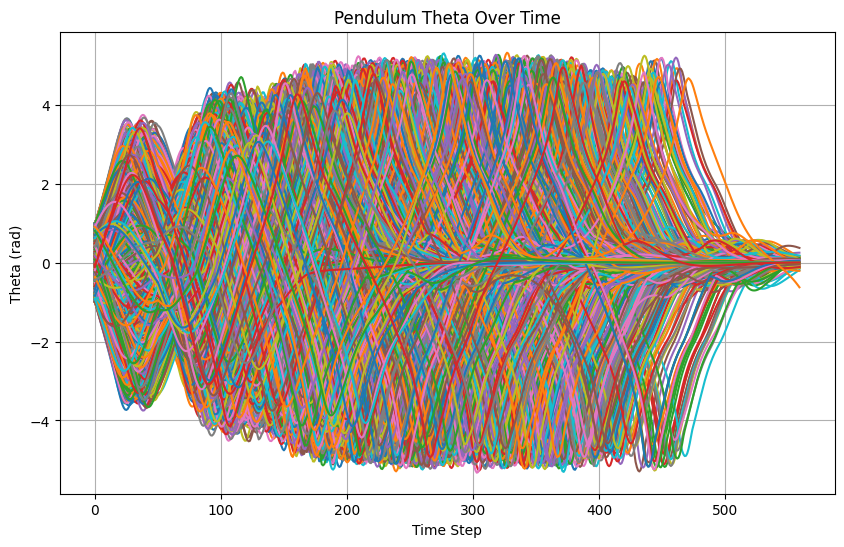

In [12]:
## plot xs_pend using matplotlib
plt.figure(figsize=(10, 6))
for i in range(xs_pend.shape[0]):
    plt.plot(np.arange(xs_pend.shape[1]), xs_pend[i, :, 3].cpu().numpy(), label=f'Pendulum {i} Theta')
plt.xlabel('Time Step')
plt.ylabel('Theta (rad)')
plt.title('Pendulum Theta Over Time')
# plt.legend()
plt.grid()
plt.show()

ys_pend shape: torch.Size([2794, 559, 2])


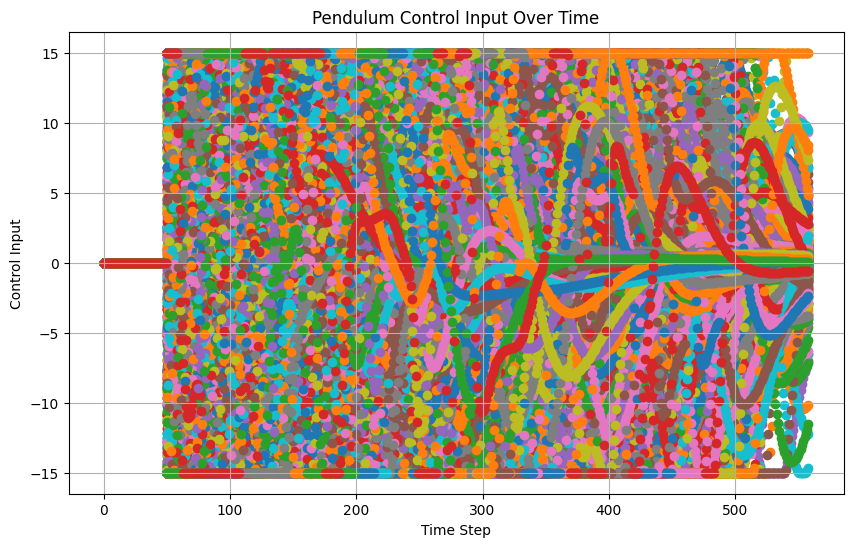

In [13]:
# plot ys_pend using matplotlib
print(f"ys_pend shape: {ys_pend.shape}")
plt.figure(figsize=(10, 6))
for i in range(ys_pend.shape[0]):
    plt.scatter(np.arange(ys_pend.shape[1]), ys_pend[i, :, 0].cpu().numpy(), label=f'Pendulum {i} Control Input')
plt.xlabel('Time Step')
plt.ylabel('Control Input')
plt.title('Pendulum Control Input Over Time')
# plt.legend()
plt.grid()
plt.show()

In [22]:
# import torch

# def compute_reward_to_go(states, controls, coeff_swingup=1.0):
#     """
#     states: tensor (B, T, 4)
#     controls: tensor (B, T-1, 2) where controls[..., 0] = control action, controls[..., 1] = label (0 or 1)
    
#     Returns:
#         reward_to_go: tensor (B, T-1)
#     """
#     B, T, _ = states.shape

#     # Extract control and label
#     u = controls[..., 0]   # shape (B, T-1)
#     labels = controls[..., 1].long()  # shape (B, T-1), should be 0 or 1

#     # For swing-up reward: parameter, for example theta = states[..., 0, :-1]
#     # Note: states are one longer in time than controls, so slice to T-1
#     theta = states[:, :-1, 2]  # shape (B, T-1)

#     # Compute swing-up reward
#     swingup_reward = torch.exp(-coeff_swingup * theta**2)  # (B, T-1)

#     # Compute LQR reward
#     Qx = torch.sum(states[:, 1:, :]**2, dim=-1)  # (B, T-1), state norm squared at next step
#     Ru = u**2  # (B, T-1)
#     lqr_reward = -(Qx + Ru)  # (B, T-1)

#     # Combine piecewise rewards by label
#     reward = torch.where(labels == 0, swingup_reward, lqr_reward)  # (B, T-1)

#     # Compute reward-to-go by cumulative sum backward along time
#     reward_to_go = torch.flip(torch.cumsum(torch.flip(reward, dims=[1]), dim=1), dims=[1])  # (B, T-1)

#     return reward_to_go, reward

# def compute_discounted_reward_to_go(rewards, gamma=0.99):
#     # rewards: [B, T], float tensor
#     B, T = rewards.shape
#     discounted_rtgs = torch.zeros_like(rewards)
#     discounted_rtgs[:, -1] = rewards[:, -1]
#     for t in reversed(range(T - 1)):
#         discounted_rtgs[:, t] = rewards[:, t] + gamma * discounted_rtgs[:, t + 1]
#     return discounted_rtgs


# # Example usage
# states = torch.stack(xs_pend, dim=0)  # Assuming xs_pend is a list of tensors
# controls = torch.stack(ys_pend, dim=0)  # Assuming ys_pend is a list of tensors
# reward_to_go, reward = compute_reward_to_go(states, controls)
# discounted_reward_to_go = compute_discounted_reward_to_go(reward)
# distance_so_far = torch.norm(states, dim=-1, keepdim=True)  # Compute distance so far
# print(f"Reward to go shape: {reward_to_go.shape}")
# print(f"Discounted reward to go shape: {discounted_reward_to_go.shape}")
# print(f"Distance so far shape: {distance_so_far.shape}")
# n = 9
# t = -1
# # print(f"Reward to go {n}: {reward_to_go[n]}")
# # print(f"Discounted reward to go {n}: {discounted_reward_to_go[n]}")
# # print(f"Distance so far {n}: {distance_so_far[n]}")
# # replace theta with cos(theta) and sin(theta) for cartpole
# cos_theta = torch.cos(states[:, :, 2])
# sin_theta = torch.sin(states[:, :, 2])
# states_new = torch.cat((states[:, :, :2], cos_theta.unsqueeze(-1), sin_theta.unsqueeze(-1), states[:, :, 3:]), dim=-1)  
# print(f"States shape after replacing theta: {states_new.shape}")
# print(f"states[n, t, :]: {states[n, t, :]}")
# print(f"states_new[n, t, :]: {states_new[n, t, :]}")
# # distance_so_far_new = torch.norm(states_new, dim=-1, keepdim=True)  # Compute distance so far with new states 
# goal_state = torch.tensor([0.0, 0.0, 1.0, 0.0, 0.0], device=states_new.device)  # Example goal state
# distance_so_far_new = torch.norm(states_new - goal_state, dim=-1, keepdim=True)  # Compute distance so far with new states
# print(f"Distance so far new shape: {distance_so_far_new.shape}")
# print(f"Distance so far new {n}: {distance_so_far_new[n]}")



# # # Visualize the reward to go for the first example
# # plt.figure(figsize=(10, 5))
# # plt.plot(reward_to_go[n].cpu().numpy(), label='Reward to Go')
# # plt.plot(discounted_reward_to_go[n].cpu().numpy(), label='Discounted Reward to Go')
# # plt.title('Reward to Go for Cartpole Example')
# # plt.xlabel('Time Step')
# # plt.ylabel('Reward to Go')
# # plt.legend()
# # plt.grid()
# # plt.show()

# # # visualize control label for first example
# # plt.figure(figsize=(10, 5))
# # # plt.plot(controls[n, :, 0].cpu().numpy(), label='Control Action')
# # plt.plot(controls[n, :, 1].cpu().numpy(), label='Label (0 or 1)')
# # plt.title('Control Action and Label for Cartpole Example')
# # plt.xlabel('Time Step')
# # plt.ylabel('Control Action / Label')
# # plt.legend()
# # plt.grid()
# # plt.show()

# # visualize distance so far for first example
# plt.figure(figsize=(10, 5))
# # plt.plot(distance_so_far[n].cpu().numpy(), label='Distance So Far')
# plt.plot(distance_so_far_new[n].cpu().numpy(), label='Distance So Far (New)')
# plt.title('Distance So Far for Cartpole Example')
# plt.xlabel('Time Step')
# plt.ylabel('Distance')
# plt.legend()
# plt.grid()
# plt.show()


In [ ]:
### plot pendulum data
testing_traj_x1= []
testing_traj_x2 = []
def plot_pendulum_data(xs):
    fig = go.Figure()
    fig2 = go.Figure()
    fig3 = go.Figure()
    fig4 = go.Figure()
    fig5 = go.Figure()
    for i in range(len(xs_pend)):
        x = xs[i][:, 2].cpu().numpy() #theta
        # x = np.where(x > 1e-3, x, 20)
        # mask = np.abs(x) > 1e-3
        # x = x[mask]
        # x = np.cos(x)
        y = xs[i][:, 3].cpu().numpy() #theta_dot

        

        # adding decaying noise to the data
        # decay = np.linspace(1, 0.01, len(x))
        # stdv = 0.01
        # noise_x = np.random.randn(len(x)) * decay * stdv
        # noise_y = np.random.randn(len(y)) * decay * stdv

        # x = x + noise_x
        # y = y + noise_y
        
        testing_traj_x1.append(x)
        testing_traj_x2.append(y)
        # fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name=f'Pendulum {i}'))
        fig.add_trace(go.Scatter(x=np.arange(len(x)), y=x, mode='lines', name=f'System {i}'))
        fig2.add_trace(go.Scatter(x=np.arange(len(x)), y=np.abs(x), mode='lines', name=f'System {i}'))
        fig3.add_trace(go.Scatter(x=np.arange(len(y)), y=y, mode='lines', name=f'System {i}'))
        fig4.add_trace(go.Scatter(x=np.arange(len(y)), y=np.abs(y), mode='lines', name=f'System {i}'))
        fig5.add_trace(go.Scatter(x=x, y=y, mode='lines', name=f'System {i}'))
        # fig.add_trace(go.Scatter(x=np.arange))
    fig.update_layout(title='Time Series theta',
                      xaxis_title='Time',
                      yaxis_title='theta')
    fig2.update_layout(title='Time Series theta(Abs)',
                      xaxis_title='Time',
                      yaxis_title='theta(Abs)',
                      yaxis_type='log')
    fig3.update_layout(title='Time Series thetadot',
                      xaxis_title='Time',
                      yaxis_title='thetadot')
    fig4.update_layout(title='Time Series thetadot (Abs)',
                      xaxis_title='Time',
                      yaxis_title='thetadot (Abs)',
                      yaxis_type='log')
    # fig5.update_layout(title='Pendulum Phase Plot',
    #                   xaxis_title='Theta',
    #                   yaxis_title='Theta Dot')

    # fig5.show()
    fig.show()
    fig2.show()
    fig3.show()
    fig4.show()
    # return

def plot_pendulum_data_scaled(xs):
    fig = go.Figure()
    fig2 = go.Figure()
    fig3 = go.Figure()
    fig4 = go.Figure()
    for i in range(len(xs_pend)):
        x = xs[i][:, 0].cpu().numpy() #theta
        y = xs[i][:, 1].cpu().numpy() #theta_dot
        # mask = np.abs(x) > 1e-3
        # x = x[mask]
        # scaled_x = (x - np.min(x)) / (np.max(x) - np.min(x))
        # scaled_y = (y - np.min(y)) / (np.max(y) - np.min(y))
        # scaled_x = [x[i] / (40 * 0.98 ** i) for i in range(len(x))]
        # scaled_y = [y[i] / (40 * 0.98 ** i) for i in range(len(y))]
        
        # scaled_x = np.sign(x) * np.log1p(1e5*np.abs(x))/10
        # scaled_y = np.sign(y) * np.log1p(1e5*np.abs(y))/15
        # a_theta = -0.0288 #-0.0274
        # b_theta = 3.5833 #1.0035

        # a_thetadot = -0.0288 #-0.0259
        # b_thetadot = 3.5833 #1.7668

        # a = -0.03869
        # b = 2.15125

        a = -0.036096496474688156
        b = 3.292495439274396

        a_theta = a
        b_theta = b

        a_thetadot = a
        b_thetadot = b

        # scaled_x = scaled_y = np.sign(y)*(np.abs(y)/(np.exp(a*np.arange(len(y))+b) + 1e-12))/75
        scaled_x = np.sign(x)*(np.abs(x)/(np.exp(a_theta*np.arange(len(x))+b_theta) + 1e-12)) #/150
        scaled_y = np.sign(y)*(np.abs(y)/(np.exp(a_thetadot*np.arange(len(y))+b_thetadot) + 1e-12)) #/150 #50

        # adding decaying noise to the data
        # decay = np.linspace(1, 0.01, len(scaled_x))
        # stdv = 0.01
        # noise_x = np.random.randn(len(scaled_x)) * decay * stdv
        # noise_y = np.random.randn(len(scaled_y)) * decay * stdv

        # scaled_x = scaled_x + noise_x
        # scaled_y = scaled_y + noise_y
        

        # first_fifty_indices = np.arange(0, 50)
        # last_threefifty_indices = np.arange(50, 400)
        # scaled_x = np.zeros_like(x)
        # scaled_y = np.zeros_like(y)
        # scaled_x[first_fifty_indices] = x[first_fifty_indices]/5
        # scaled_y[first_fifty_indices] = y[first_fifty_indices]/15

        # scaled_x[last_threefifty_indices] = x[last_threefifty_indices]/(5*0.98**(last_threefifty_indices-50))
        # scaled_y[last_threefifty_indices] = y[last_threefifty_indices]/(5*0.98**(last_threefifty_indices-50))
        # scaled_x = np.arcsinh(x/1e-3)/8
        # scaled_y = np.arcsinh(y/1e-3)/8
        # fig.add_trace(go.Scatter(x=scaled_x, y=scaled_y, mode='markers', name=f'Pendulum {i}'))
        fig.add_trace(go.Scatter(x=np.arange(len(scaled_x)), y=scaled_x, mode='lines', name=f'System {i}'))
        fig2.add_trace(go.Scatter(x=np.arange(len(scaled_x)), y=np.abs(scaled_x), mode='lines', name=f'System {i}'))
        fig3.add_trace(go.Scatter(x=np.arange(len(scaled_y)), y=scaled_y, mode='lines', name=f'System {i}'))
        fig4.add_trace(go.Scatter(x=np.arange(len(scaled_y)), y=np.abs(scaled_y), mode='lines', name=f'System {i}'))
    fig.update_layout(title='Scaled x1',
                      xaxis_title='Time',
                      yaxis_title='Scaled x1'
                      )
    fig2.update_layout(title='Scaled x1 (Abs)',
                      xaxis_title='Time',
                      yaxis_title='Scaled x1 (Abs)',
                      yaxis_type='log'
                      )
    fig3.update_layout(title='Scaled x2',
                      xaxis_title='Time',
                      yaxis_title='Scaled x2'
                      )
    fig4.update_layout(title='Scaled x2 (Abs)',
                      xaxis_title='Time',
                      yaxis_title='Scaled x2 (Abs)',
                      yaxis_type='log'
                      )
    
    
    fig.show()
    fig2.show()
    fig3.show()
    fig4.show()


plot_pendulum_data(xs_pend)
print("--" * 50)
# plot_pendulum_data_scaled(xs_pend)

In [14]:
### plot pendulum control inputs
# testing_traj_ebonye = []
# ys_pend_stacked = torch.stack(ys_pend, dim=0)
# ys_pend_stacked_scaled = np.sign(ys_pend_stacked.cpu().numpy()) * np.log1p(1e7*np.abs(ys_pend_stacked.cpu().numpy()))/20
# mean_ys_pend = np.mean(ys_pend_stacked_scaled, axis=(0, 1))
# std_ys_pend = np.std(ys_pend_stacked_scaled, axis=(0, 1))
# print(f"Mean of ys_pend: {mean_ys_pend}")

def percentile_of_max(ys):
    max_values = []
    for i in range(len(xs_pend)):
        y = ys[i][:].cpu().numpy() #control input
        max_values.append(np.max(np.abs(y)))
    # print(f"Max values: {max_values}")
    # print(f"95th percentile of max of all: {np.percentile(max_values, 95)}")
    return np.percentile(max_values, 95)

def plot_pendulum_controls(ys):
    fig = go.Figure()
    fig2 = go.Figure()
    for i in range(len(xs_pend)):
        y = ys[i][:,0].cpu().numpy() #control input
        fig.add_trace(go.Scatter(x=np.arange(len(y)), y=y, mode='lines', name=f'System {i}'))
        fig2.add_trace(go.Scatter(x=np.arange(len(y)), y=np.abs(y), mode='lines', name=f'Systemlum {i}'))
        # testing_traj_ebonye.append(y)
        # if i == 30:
        #     # print(y)
        #     # testing_traj_ebonye = y
        #     testing_traj_ebonye.append(y)
    fig.update_layout(title='Cartpole Control Inputs',
                      xaxis_title='Time Step',
                      yaxis_title='Control Input')
    fig2.update_layout(title='Cartpole Control Inputs (Abs)',
                      xaxis_title='Time Step',
                      yaxis_title='Control Input (Abs)',
                      yaxis_type='log'
                      )
    fig.show()
    fig2.show()

def plot_pendulum_controls_scaled(ys):
    fig = go.Figure()
    fig2 = go.Figure()
    for i in range(len(xs_pend)):
        y = ys[i][:].cpu().numpy() #control input

        ## exponential scaling
        # a = -0.03869
        # b = 2.15125

        ## most recent scaling
        # a = -0.036096496474688156
        # b = 3.292495439274396

        a = 0.04436470423989572
        b = -8.894677778040512

        

        scaled_y = np.sign(y)*(np.abs(y)/(np.exp(a*np.arange(len(y))+b) + 1e-12)) #/150 #75
        # scaled_y = (y )/ (400) ### approximate min-max scaling
        ### scaled_y = [y[i]/(400*0.98**i) for i in range(len(y))]
        # scaled_y = np.sign(y) * np.log1p(1e6*np.abs(y))/20
        # print(np.sign(y))
        ## normalize to mean 0 and std 1
        # scaled_y = (scaled_y - mean_ys_pend) / std_ys_pend


        # scaled_y = np.array(y)/(400*0.98**np.arange(len(y)))
        # idxs = np.arange(300) + 100
        # scaled_y[idxs] = scaled_y[idxs] * 4
        # first_hundred_idxs = np.arange(100)
        # last_three_hundred_idxs = np.arange(100, 400)
        # scaled_y = np.zeros_like(y)
        # scaled_y[first_hundred_idxs] = y[first_hundred_idxs] / (200 * 0.98 ** (1*first_hundred_idxs))
        # scaled_y[last_three_hundred_idxs] = y[last_three_hundred_idxs] / (30 * 0.985 ** (1.5*(last_three_hundred_idxs-100)))
        # scaled_y[last_three_hundred_idxs] = y[last_three_hundred_idxs] / (1/5)

        # scaled_y = np.sign(y) * np.log(np.abs(y)+1e-9)
        # first_points.append(scaled_y[0])
        # last_points.append(scaled_y[-1])
        # scaled_y = np.sign(y) * np.log1p(np.abs(y)/1e-3)/10
        # scaled_y = np.arcsinh(y/1e-3)/8
        # scaled_y = [np.sign(y[i]) * np.log1p(np.abs(y)[i])/(np.log(1+40)*0.98**i) for i in range(len(y))]
        if i == 13:
            testing_traj_scale.append(scaled_y)
            testing_traj.append(y)
            # print('hello')
            # print(f"95th percentile of y: {np.percentile(np.abs(y), 95)}")
            # 95th percentile of max of all
            # print(f"y: {y}")
            # print(f"scaled_y: {np.array(scaled_y)}")
        # scaled_y = np.sign(y) * np.log1p(np.abs(y))

        fig.add_trace(go.Scatter(x=np.arange(len(scaled_y)), y=scaled_y, mode='lines', name=f'System {i}'))
        fig2.add_trace(go.Scatter(x=np.arange(len(scaled_y)), y=np.abs(scaled_y), mode='lines', name=f'System {i}'))
    fig.update_layout(title='Scaled Linear System Control Inputs',
                      xaxis_title='Time Step',
                      yaxis_title='Control Input'
                      )
    fig2.update_layout(title='Scaled Linear System Control Inputs (Abs)',
                      xaxis_title='Time Step',
                      yaxis_title='Scaled Control Input',
                      yaxis_type='log'
                      )
    fig.show()
    fig2.show()
first_points = []
last_points = []
testing_traj_scale = []
testing_traj = []
plot_pendulum_controls(ys_pend)
# print(f"ys_pend shape: {torch.stack(ys_pend, dim=0).shape}")
# plot_pendulum_controls_scaled(ys_pend)
# print(percentile_of_max(ys_pend))

# print(torch.stack(ys_pend, dim=0).shape)
# print(f"mean of ys_pend: {torch.mean(torch.stack(ys_pend, dim=0), dim=0)}")
# print(f"std of ys_pend: {torch.std(torch.stack(ys_pend, dim=0), dim=0)}")



In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# # Sample data with negative y values
# # x = np.array([0, 1, 2, 3, 4])
# # y = np.array([-1.0, -2.7, -7.4, -20.1, -55.5])  # example of negative exponential
# y_unabs = testing_traj_ebonye[21]
# y = np.abs(testing_traj_ebonye[21])
# x = np.arange(len(y))

# # print(y)

# # Define exponential model: y = a * exp(b * x)
# def exp_func(x, a, b):
#     return a * np.exp(b * x)

# # # Fit curve
# # popt, pcov = curve_fit(exp_func, x, y)
# # a, b = popt

# # # Predict
# # x_fit = np.linspace(min(x), max(x), 100)
# # y_fit = exp_func(x_fit, a, b)

# # # Plot
# # plt.scatter(x, y, label="Data")
# # plt.plot(x_fit, y_fit, color='red', label=f"Fit: {a:.2f} * exp({b:.2f} x)")
# # plt.legend()
# # plt.xlabel("x")
# # plt.ylabel("y")
# # plt.title("Exponential Fit using curve_fit")
# # plt.show()



# epsilon = 1e-12
# log_y = np.log(y + epsilon)


# def linear_model(x, a, b):
#     return a * x + b

# # Fit the linear
# params, _ = curve_fit(linear_model, x, log_y)
# fitted_log_y = linear_model(x, *params)
# fitted_y = np.exp(fitted_log_y)

# # print parameters
# a, b = params
# print(f"Fitted parameters: a = {a}, b = {b}")
# # print(f"Fitted y: {fitted_y}")

# # plt.scatter(x, y, label="Original")
# # plt.plot(x, fitted_y, label="Fitted", linestyle='--')
# # plt.legend()
# # plt.yscale('log')
# # plt.show()


# ## scale the y values by the fitted parameters
# # new_scaled_y = np.array([y[i]/(a*np.exp(b*i)) for i in range(len(y))])
# # print(f"New scaled y: {new_scaled_y}")
# new_scaled_y = y_unabs / fitted_y
# # print(f"New scaled y: {new_scaled_y}")





In [16]:
# y = torch.linspace(-1, 1, 9)
# scaled_y0 = torch.sign(y) * torch.log1p(1e5 * torch.abs(y)) / 10
# scaled_y1 = torch.sign(y) * torch.log1p(1e5 * torch.abs(y)) / 15
# scaled = torch.stack([scaled_y0, scaled_y1], dim=1)

# # unscaled = undo_piecewise_scaling_states(scaled)
# unscaled = torch.zeros_like(scaled)
# for i in range(scaled.shape[0]):
#     unscaled[i, 0] = torch.sign(scaled[i, 0]) * (torch.expm1((scaled[i, 0]) * 10) * 1e-5)
#     unscaled[i, 1] = torch.sign(scaled[i, 1]) * (torch.expm1((scaled[i, 1]) * 15) * 1e-5)
# # assert torch.allclose(unscaled[:,0], y, atol=1e-3)
# # assert torch.allclose(unscaled[:,1], y, atol=1e-3)

# print(f"original y: {y}")
# print(f"Unscaled: {unscaled}")
# print(f"Scaled: {scaled}")


In [ ]:
# print(f"testing_traj_ebonye len: {len(testing_traj_ebonye)}")
# print(f"testing_traj_theta len: {len(testing_traj_theta)}")
# print(f"testing_traj_thetadot len: {len(testing_traj_thetadot)}")

# # testing_traj_eb = np.stack(testing_traj_ebonye, axis=0)
# # y_all_before = np.concatenate(testing_traj_ebonye, axis=0)
# y_all = testing_traj_ebonye[54]
# log_y_all = np.log(np.abs(y_all) + epsilon)
# # y_all = y_all_before #/400
# # # log_y_all = np.log(np.abs(y_all) + epsilon)
# x = np.arange(len(testing_traj_ebonye[0]))
# x_all = x
# # x_all = np.concatenate([x for _ in range(len(testing_traj_ebonye))], axis=0)

# theta_all = testing_traj_theta[60]
# thetadot_all = testing_traj_thetadot[41]
# log_theta_all = np.log(np.abs(theta_all) + epsilon)
# log_thetadot_all = np.log(np.abs(thetadot_all) + epsilon)
# x_all_states = np.arange(len(testing_traj_theta[0]))


# print(f"y_all shape: {y_all.shape}")
# print(f"x_all shape: {x_all.shape}")

# def linear_model(x, a, b):
#     return a * x + b

# params, _ = curve_fit(linear_model, x_all, log_y_all)
# a, b = params
# print(f"Fitted global model: |y| ≈ exp({a:.4f} * x + {b:.4f})")

# params_theta, _ = curve_fit(linear_model, x_all_states, log_theta_all)
# a_theta, b_theta = params_theta
# print(f"Fitted global model: |theta| ≈ exp({a_theta:.4f} * x + {b_theta:.4f})")

# params_thetadot, _ = curve_fit(linear_model, x_all_states, log_thetadot_all)
# a_thetadot, b_thetadot = params_thetadot
# print(f"Fitted global model: |thetadot| ≈ exp({a_thetadot:.4f} * x + {b_thetadot:.4f})")

# def scale(traj, a =a, b=b):
#     # x = np.arange(len(traj))
#     # exp_fit = np.exp(a*x + b)
#     # scaled = (np.abs(traj) / (exp_fit + epsilon)) * np.sign(traj)
#     # log_traj = np.log(np.abs(traj) + epsilon)
#     # expected_log = a * x + b
#     # scaled = (log_traj - expected_log) * np.sign(traj)
#     num_traj, traj_len = traj.shape
#     x = np.arange(traj_len)
#     x_broadcast = np.tile(x, (num_traj, 1))

#     exp_fit = np.exp(a * x_broadcast + b)
#     scaled = (np.abs(traj) / (exp_fit + epsilon)) * np.sign(traj)

#     # log_traj = np.log(np.abs(traj) + epsilon)
#     # expected_log = a * x_broadcast + b
#     # residual = (log_traj - expected_log) 
#     # scaled = residual
#     # # scaled = (residual - np.mean(residual, axis=1, keepdims=True)) / (np.std(residual, axis=1, keepdims=True) + epsilon)
#     # scaled *= np.sign(traj)
#     return scaled

# y_all_total = np.stack(testing_traj_ebonye, axis=0)
# theta_all_total = np.stack(testing_traj_theta, axis=0)
# thetadot_all_total = np.stack(testing_traj_thetadot, axis=0)
# scaled_y_all = scale(y_all_total, a, b)
# scaled_theta_all = scale(theta_all_total, a_theta, b_theta)
# scaled_thetadot_all = scale(thetadot_all_total, a_thetadot, b_thetadot)
# # scaled_y_all = scale(y_all, a, b)

# print(f"Original y_all shape: {y_all_total.shape}")
# print(f"Scaled y_all shape: {scaled_y_all.shape}")

# ## reshape scaled_y_all
# # scaled_y_all = scaled_y_all.reshape(len(testing_traj_ebonye), -1)
# # y_all = y_all.reshape(len(testing_traj_ebonye), -1)
# # print(f"Scaled y_all shape: {scaled_y_all.shape}")
# # print(f"Original y_all[2]: {y_all[2]}")
# # print(f"Scaled y_all[2]: {scaled_y_all[2]}")


# # visualize the scaled y_all and unscaled y_all
# # fig = go.Figure()
# # fig2 = go.Figure()
# # for i in range(len(testing_traj_ebonye)):
# #     fig.add_trace(go.Scatter(x=np.arange(len(scaled_y_all[i])), y=scaled_y_all[i], mode='lines', name=f'Scaled Pendulum {i}'))
# #     fig2.add_trace(go.Scatter(x=np.arange(len(y_all[i])), y=y_all[i], mode='lines', name=f'Original Pendulum {i}'))
# # fig.update_layout(title='Scaled Pendulum Control Inputs',
# #                   xaxis_title='Time Step',
# #                   yaxis_title='Control Input')
# # fig2.update_layout(title='Original Pendulum Control Inputs',
# #                   xaxis_title='Time Step',
# #                   yaxis_title='Control Input')
# # fig.show()
# # fig2.show()

# ## visualize the scaled y_all_total and unscaled y_all_total
# fig = go.Figure()
# fig2 = go.Figure()
# for i in range(len(testing_traj_ebonye)):
#     fig.add_trace(go.Scatter(x=np.arange(len(scaled_y_all[i])), y=np.abs(scaled_y_all[i]/70), mode='lines', name=f'Pend {i}'))
#     fig2.add_trace(go.Scatter(x=np.arange(len(y_all_total[i])), y=np.abs(y_all_total[i]), mode='lines', name=f'Pend {i}'))
# fig.update_layout(title='Scaled Pendulum Control Inputs',
#                   xaxis_title='Time Step',
#                   yaxis_title='Control Input',
#                   yaxis_type='log'
#                   )
# fig2.update_layout(title='Original Pendulum Control Inputs',
#                   xaxis_title='Time Step',
#                   yaxis_title='Control Input',
#                   yaxis_type='log'
#                   )
# fig3 = go.Figure()
# fig4 = go.Figure()
# for i in range(len(testing_traj_theta)):
#     fig3.add_trace(go.Scatter(x=np.arange(len(scaled_theta_all[i])), y=np.abs(scaled_theta_all[i]/150), mode='lines', name=f'Theta {i}'))
#     fig4.add_trace(go.Scatter(x=np.arange(len(theta_all_total[i])), y=np.abs(theta_all_total[i]), mode='lines', name=f'Theta {i}'))
# fig3.update_layout(title='Scaled Pendulum Theta',
#                   xaxis_title='Time Step',
#                   yaxis_title='Theta',
#                   yaxis_type='log'
#                   )
# fig4.update_layout(title='Original Pendulum Theta',
#                   xaxis_title='Time Step',
#                   yaxis_title='Theta',
#                   yaxis_type='log'
#                   )

# fig5 = go.Figure()
# fig6 = go.Figure()
# for i in range(len(testing_traj_thetadot)):
#     fig5.add_trace(go.Scatter(x=np.arange(len(scaled_thetadot_all[i])), y=np.abs(scaled_thetadot_all[i]/50), mode='lines', name=f'Theta Dot {i}'))
#     fig6.add_trace(go.Scatter(x=np.arange(len(thetadot_all_total[i])), y=np.abs(thetadot_all_total[i]), mode='lines', name=f'Theta Dot {i}'))
# fig5.update_layout(title='Scaled Pendulum Theta Dot',
#                   xaxis_title='Time Step',
#                   yaxis_title='Theta Dot',
#                   yaxis_type='log'
#                   )
# fig6.update_layout(title='Original Pendulum Theta Dot',
#                   xaxis_title='Time Step',
#                   yaxis_title='Theta Dot',
#                   yaxis_type='log'
#                   )

# fig.show()
# fig2.show()
# fig3.show()
# fig4.show()
# fig5.show()
# fig6.show()

In [ ]:
# 